# AQI Prediction Model v2

This notebook retrains the AQI prediction model using **only features available via the Open-Meteo Air Quality API**:

| Open-Meteo Parameter | Maps to Training Column |
|---|---|
| `pm2_5` | `PM2.5` |
| `pm10` | `PM10` |
| `carbon_monoxide` (µg/m³ ÷ 1000) | `CO` (mg/m³) |
| `nitrogen_dioxide` | `NO2` |
| `sulphur_dioxide` | `SO2` |
| `ozone` | `O3` |
| `ammonia` | `NH3` |
| `us_aqi` (past 3 days) | `AQI_lag1`, `AQI_lag2`, `AQI_lag3`, `AQI_roll3` |

Dropped columns (NOT in Open-Meteo): `NO`, `NOx`, `Benzene`, `Toluene`, `Xylene`, `Year`

In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## Step 1: Load & Clean Data

In [2]:
df = pd.read_csv('./data/city_day.csv')

# Drop rows with no AQI (target)
df = df.dropna(subset=['AQI'])

# Drop columns NOT available via Open-Meteo
cols_to_drop = ['NO', 'NOx', 'Benzene', 'Toluene', 'AQI_Bucket']
if 'Xylene' in df.columns:
    cols_to_drop.append('Xylene')
df = df.drop(columns=cols_to_drop, errors='ignore')

# Parse date
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df = df.sort_values(by=['City', 'Date']).reset_index(drop=True)

print(f'Shape after cleaning: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape after cleaning: (24850, 10)
Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'AQI']


,City,Date,PM2.5,PM10,NO2,NH3,CO,SO2,O3,AQI
0,Ahmedabad,2015-01-29,83.13,NaN,28.71,NaN,6.93,49.52,59.76,209.0
1,Ahmedabad,2015-01-30,79.84,NaN,28.68,NaN,13.85,48.49,97.07,328.0
2,Ahmedabad,2015-01-31,94.52,NaN,32.66,NaN,24.39,67.39,111.33,514.0
3,Ahmedabad,2015-02-01,135.99,NaN,42.08,NaN,43.48,75.23,102.70,782.0
4,Ahmedabad,2015-02-02,178.33,NaN,35.31,NaN,54.56,55.04,107.38,914.0


In [3]:
# Fill missing pollutant values with per-city median
pollutant_cols = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'NH3']

for col in pollutant_cols:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

# Fill remaining NaNs with global median
for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

print('Missing values after imputation:')
print(df[pollutant_cols + ['AQI']].isnull().sum())

Missing values after imputation:
PM2.5    0
PM10     0
CO       0
NO2      0
SO2      0
O3       0
NH3      0
AQI      0
dtype: int64


## Step 2: Engineer Lag Features from AQI

In [4]:
# Create lag features per city (sort is already done above)
df['AQI_lag1'] = df.groupby('City')['AQI'].shift(1)
df['AQI_lag2'] = df.groupby('City')['AQI'].shift(2)
df['AQI_lag3'] = df.groupby('City')['AQI'].shift(3)
df['AQI_roll3'] = (
    df['AQI_lag1'] + df['AQI_lag2'] + df['AQI_lag3']
) / 3

# Drop rows where lag features can't be computed
df = df.dropna(subset=['AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_roll3'])

print(f'Shape after lag feature engineering: {df.shape}')
df[['City', 'Date', 'AQI', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_roll3']].head(10)

Shape after lag feature engineering: (24772, 14)


,City,Date,AQI,AQI_lag1,AQI_lag2,AQI_lag3,AQI_roll3
3,Ahmedabad,2015-02-01,782.0,514.0,328.0,209.0,350.333333
4,Ahmedabad,2015-02-02,914.0,782.0,514.0,328.0,541.333333
5,Ahmedabad,2015-02-03,660.0,914.0,782.0,514.0,736.666667
6,Ahmedabad,2015-02-04,294.0,660.0,914.0,782.0,785.333333
7,Ahmedabad,2015-02-05,149.0,294.0,660.0,914.0,622.666667
8,Ahmedabad,2015-02-06,190.0,149.0,294.0,660.0,367.666667
9,Ahmedabad,2015-02-07,247.0,190.0,149.0,294.0,211.000000
10,Ahmedabad,2015-02-08,379.0,247.0,190.0,149.0,195.333333
11,Ahmedabad,2015-02-09,341.0,379.0,247.0,190.0,272.000000
12,Ahmedabad,2015-02-10,256.0,341.0,379.0,247.0,322.333333


## Step 3: Prepare Features & Target

In [5]:
FEATURES = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3',
            'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_roll3']

TARGET = 'AQI'

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {FEATURES}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'y stats: min={y.min():.1f}, max={y.max():.1f}, mean={y.mean():.1f}')

Features: ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_roll3']
X shape: (24772, 10)
y shape: (24772,)
y stats: min=13.0, max=2049.0, mean=166.4


## Step 4: Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')

Train size: 19817
Test size:  4955


## Step 5: Train Random Forest Model

In [7]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

print('Training model...')
model.fit(X_train, y_train)
print('Training complete!')

Training model...
Training complete!


## Step 6: Evaluate Model

In [8]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²:   {r2:.4f}')

MAE:  18.02
RMSE: 41.00
R²:   0.9096


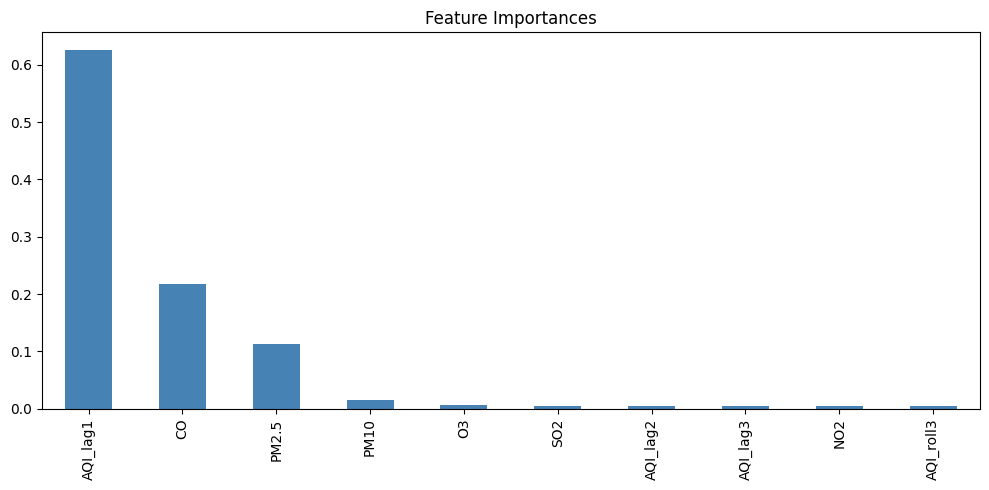

AQI_lag1     0.625535
CO           0.217315
PM2.5        0.112874
PM10         0.014678
O3           0.006223
SO2          0.005293
AQI_lag2     0.005258
AQI_lag3     0.004529
NO2          0.004460
AQI_roll3    0.003836
dtype: float64


In [9]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

print(importances)

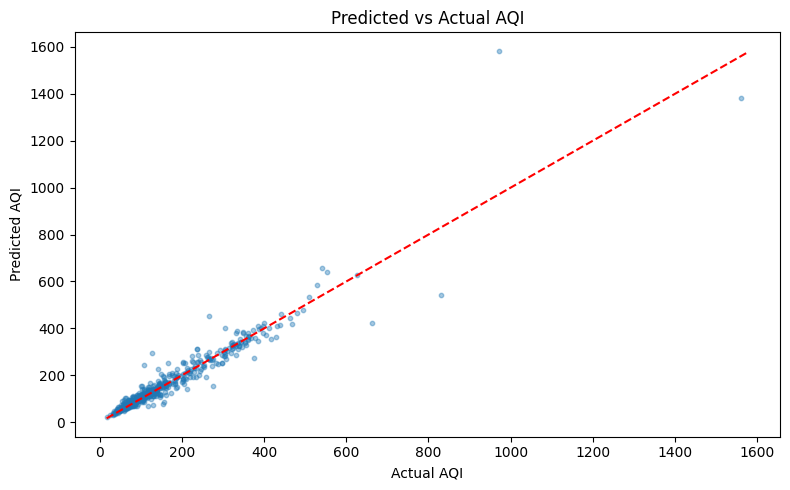

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test[:500], y_pred[:500], alpha=0.4, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Predicted vs Actual AQI')
plt.tight_layout()
plt.show()

## Step 7: Save Model

In [11]:
output_path = './model_server/aqi_model.pkl'
joblib.dump(model, output_path ,compress=3)
print(f'Model saved to: {output_path}')
print(f'Feature names stored in model: {list(model.feature_names_in_)}')

Model saved to: ./model_server/aqi_model.pkl
Feature names stored in model: ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3', 'AQI_lag1', 'AQI_lag2', 'AQI_lag3', 'AQI_roll3']


## Step 8: Quick Sanity Check — Simulate API Inference

In [12]:
# Simulate what the backend will receive from the frontend
# (values from Open-Meteo for a typical polluted day)
sample = {
    'PM2.5': 68.0,
    'PM10': 120.0,
    'CO': 0.8,        # converted from µg/m³ to mg/m³
    'NO2': 28.0,
    'SO2': 14.0,
    'O3': 34.0,
   
    'AQI_lag1': 150.0,
    'AQI_lag2': 140.0,
    'AQI_lag3': 130.0,
    'AQI_roll3': 140.0  # (150+140+130)/3
}

loaded_model = joblib.load(output_path)
input_array = np.array([[sample[f] for f in loaded_model.feature_names_in_]])

# Simulate 3-day rolling forecast
forecasts = []
lag1_idx = list(loaded_model.feature_names_in_).index('AQI_lag1')
lag2_idx = list(loaded_model.feature_names_in_).index('AQI_lag2')
lag3_idx = list(loaded_model.feature_names_in_).index('AQI_lag3')
roll_idx = list(loaded_model.feature_names_in_).index('AQI_roll3')

for _ in range(3):
    pred = loaded_model.predict(input_array)[0]
    forecasts.append(round(float(pred), 1))
    
    lag1 = input_array[0][lag1_idx]
    lag2 = input_array[0][lag2_idx]
    
    input_array[0][lag3_idx] = lag2
    input_array[0][lag2_idx] = lag1
    input_array[0][lag1_idx] = pred
    input_array[0][roll_idx] = (input_array[0][lag1_idx] + input_array[0][lag2_idx] + input_array[0][lag3_idx]) / 3

print(f'3-Day Forecast AQI: {forecasts}')

3-Day Forecast AQI: [141.1, 135.6, 134.7]
